Images

In [ ]:
from google.colab import files
from pathlib import Path
from PIL import Image, ImageOps
import shutil
import os

ROOT = Path("/content/workspace_reconstruction")
IMAGE_DIR = ROOT / "images"

if ROOT.exists():
    shutil.rmtree(ROOT)

IMAGE_DIR.mkdir(parents=True, exist_ok=True)

uploaded = files.upload()

for filename, content in uploaded.items():
    input_path = Path("/content") / filename
    input_path.write_bytes(content)

    try:
        # Fix phone EXIF orientation and convert every image to RGB JPEG.
        image = Image.open(input_path)
        image = ImageOps.exif_transpose(image).convert("RGB")

        output_path = IMAGE_DIR / f"{Path(filename).stem}.jpg"
        image.save(output_path, quality=95)
    except Exception as exc:
        print(f"Skipping {filename}: {exc}")

image_paths = sorted(IMAGE_DIR.glob("*.jpg"))

print(f"Saved {len(image_paths)} images in {IMAGE_DIR}")
for path in image_paths:
    print(path.name)

Saving WhatsApp Image 2026-08-03 at 12.59.19(9).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(9) (2).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(8).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(8) (2).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(7).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(7) (2).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(6).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(6) (2).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(5).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(5) (2).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(4).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(4) (2).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(3).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(3) (2).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(2).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(2) (2).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(1).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(1) (2).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19.j

In [ ]:
from google.colab import files
from pathlib import Path
from PIL import Image, ImageOps
import shutil
import os

ROOT = Path("/content/workspace_reconstruction")
IMAGE_DIR = ROOT / "images"

if ROOT.exists():
    shutil.rmtree(ROOT)

IMAGE_DIR.mkdir(parents=True, exist_ok=True)

uploaded = files.upload()

for filename, content in uploaded.items():
    input_path = Path("/content") / filename
    input_path.write_bytes(content)

    try:
        # Fix phone EXIF orientation and convert every image to RGB JPEG.
        image = Image.open(input_path)
        image = ImageOps.exif_transpose(image).convert("RGB")

        output_path = IMAGE_DIR / f"{Path(filename).stem}.jpg"
        image.save(output_path, quality=95)
    except Exception as exc:
        print(f"Skipping {filename}: {exc}")

image_paths = sorted(IMAGE_DIR.glob("*.jpg"))

print(f"Saved {len(image_paths)} images in {IMAGE_DIR}")
for path in image_paths:
    print(path.name)

Saving WhatsApp Image 2026-08-03 at 12.59.19(9).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(9) (3).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(8).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(8) (3).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(7).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(7) (3).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(6).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(6) (3).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(5).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(5) (3).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(4).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(4) (3).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(3).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(3) (3).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(2).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(2) (3).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19(1).jpeg to WhatsApp Image 2026-08-03 at 12.59.19(1) (3).jpeg
Saving WhatsApp Image 2026-08-03 at 12.59.19.j

## SfM

In [ ]:
!pip -q install pycolmap

run sfm

In [ ]:
from pathlib import Path
import pycolmap
import shutil

SFM_DIR = ROOT / "sfm"
DATABASE_PATH = ROOT / "database.db"

if DATABASE_PATH.exists():
    DATABASE_PATH.unlink()

if SFM_DIR.exists():
    shutil.rmtree(SFM_DIR)

SFM_DIR.mkdir(parents=True, exist_ok=True)

pycolmap.set_random_seed(0)

print("1. Extracting SIFT features...")
pycolmap.extract_features(
    database_path=DATABASE_PATH,
    image_path=IMAGE_DIR,
)

print("2. Matching every image pair...")
pycolmap.match_exhaustive(
    database_path=DATABASE_PATH,
)

print("3. Estimating cameras and triangulating points...")
reconstructions = pycolmap.incremental_mapping(
    database_path=DATABASE_PATH,
    image_path=IMAGE_DIR,
    output_path=SFM_DIR,
)

print(f"Number of reconstructed models: {len(reconstructions)}")

1. Extracting SIFT features...
2. Matching every image pair...
3. Estimating cameras and triangulating points...
Number of reconstructed models: 2


In [ ]:
if len(reconstructions) == 0:
    print("COLMAP could not initialize a reconstruction. No models were found.")
    # Set reconstruction to None to indicate failure and allow subsequent cells to handle it.
    reconstruction = None
    model_id = None
else:
    # Select the reconstruction containing the most registered images.
    model_id, reconstruction = max(
        reconstructions.items(),
        key=lambda item: item[1].num_reg_images(),
    )

if reconstruction is not None:
    print("Selected model:", model_id)
    print("Input images:", len(image_paths))
    print("Registered images:", reconstruction.num_reg_images())
    print("Sparse 3D points:", reconstruction.num_points3D())
    print("Cameras:", reconstruction.num_cameras())

    print("\nReconstruction summary:")
    print(reconstruction.summary())


Selected model: 1
Input images: 20
Registered images: 19
Sparse 3D points: 1045
Cameras: 19

Reconstruction summary:
Reconstruction:
	num_rigs = 19
	num_cameras = 19
	num_frames = 19
	num_reg_frames = 19
	num_images = 19
	num_points3D = 1045
	num_observations = 3974
	mean_track_length = 3.80287
	mean_observations_per_image = 209.158
	mean_reprojection_error = 0.880664


inspect each camera pose

In [ ]:
import numpy as np

if 'reconstruction' in locals() and reconstruction is not None:
    for image_id, image in reconstruction.images.items():
        if not image.has_pose:
            continue

        cam_from_world = image.cam_from_world()

        print("=" * 60)
        print("Image:", image.name)
        print("Image ID:", image_id)
        print("Camera ID:", image.camera_id)
        print("World-to-camera rotation:\n", cam_from_world.rotation.matrix())
        print("World-to-camera translation:", cam_from_world.translation)
else:
    print("Skipping camera pose printing: No valid reconstruction found.")


Image: WhatsApp Image 2026-08-03 at 12.59.15 (3).jpg
Image ID: 1
Camera ID: 2
World-to-camera rotation:
 [[ 0.88578262 -0.43915293  0.15011278]
 [ 0.42457     0.63614989 -0.64424656]
 [ 0.18742853  0.63439579  0.74994168]]
World-to-camera translation: [1.1272345  1.46871273 0.83101437]
Image: WhatsApp Image 2026-08-03 at 12.59.14 (3).jpg
Image ID: 2
Camera ID: 1
World-to-camera rotation:
 [[ 0.27895317  0.72575048 -0.62886514]
 [-0.81136031  0.5284224   0.24992843]
 [ 0.51369211  0.44051788  0.73625024]]
World-to-camera translation: [ 1.41251941 -3.23269671  2.72497179]
Image: WhatsApp Image 2026-08-03 at 12.59.15(1) (3).jpg
Image ID: 3
Camera ID: 3
World-to-camera rotation:
 [[ 0.99718166 -0.07465787 -0.00741242]
 [ 0.07012452  0.9626099  -0.26165767]
 [ 0.02667007  0.26040044  0.96513228]]
World-to-camera translation: [ 0.72630784 -1.18773937  1.12614968]
Image: WhatsApp Image 2026-08-03 at 12.59.15(2) (3).jpg
Image ID: 4
Camera ID: 4
World-to-camera rotation:
 [[ 9.81431234e-01 -1.8

inspecting camera centers

In [ ]:
camera_names = []
camera_centres = []

if 'reconstruction' in locals() and reconstruction is not None:
    for image_id, image in reconstruction.images.items():
        if not image.has_pose:
            continue

        transform = image.cam_from_world()
        R = transform.rotation.matrix()
        t = np.asarray(transform.translation)

        centre = -R.T @ t

        camera_names.append(image.name)
        camera_centres.append(centre)

    camera_centres = np.asarray(camera_centres)

    print("Camera-centre array shape:", camera_centres.shape)

    for name, centre in zip(camera_names, camera_centres):
        print(name, "->", centre)
else:
    print("Skipping camera center calculation: No valid reconstruction found.")


Camera-centre array shape: (19, 3)
WhatsApp Image 2026-08-03 at 12.59.15 (3).jpg -> [-1.77781191 -0.96648514  0.1537885 ]
WhatsApp Image 2026-08-03 at 12.59.14 (3).jpg -> [-4.41670506 -0.5173061  -0.31003408]
WhatsApp Image 2026-08-03 at 12.59.15(1) (3).jpg -> [-0.67100569  0.90430439 -1.39228083]
WhatsApp Image 2026-08-03 at 12.59.15(2) (3).jpg -> [-0.28703285  2.82079253 -1.16212557]
WhatsApp Image 2026-08-03 at 12.59.18 (3).jpg -> [3.08969684 1.38336463 0.3711142 ]
WhatsApp Image 2026-08-03 at 12.59.18(1) (3).jpg -> [ 1.41063811  1.25980556 -0.44866812]
WhatsApp Image 2026-08-03 at 12.59.18(2) (3).jpg -> [-1.35887692 -2.15598975  0.25343548]
WhatsApp Image 2026-08-03 at 12.59.18(3) (3).jpg -> [ 0.19297444 -1.08469691 -1.41173352]
WhatsApp Image 2026-08-03 at 12.59.18(4) (3).jpg -> [ 1.41190611 -2.35631568  2.36741508]
WhatsApp Image 2026-08-03 at 12.59.18(5) (3).jpg -> [ 1.74916688 -2.51446571  3.26239281]
WhatsApp Image 2026-08-03 at 12.59.19 (3).jpg -> [ 3.31663938 -2.32525497  3.

visualize sparse point cloud

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

xyz = []
rgb = []

if 'reconstruction' in locals() and reconstruction is not None:
    for point_id, point in reconstruction.points3D.items():
        xyz.append(np.asarray(point.xyz))
        rgb.append(np.asarray(point.color) / 255.0)

    xyz = np.asarray(xyz)
    rgb = np.asarray(rgb)

    print("Point cloud shape:", xyz.shape)
    print("First five points:\n", xyz[:5])
else:
    print("Skipping point cloud generation: No valid reconstruction found.")


Point cloud shape: (1045, 3)
First five points:
 [[ 0.09002052  1.65551808  4.90149348]
 [ 1.22121057  1.47228856  4.84926615]
 [ 1.35839414  3.27650015  3.81792618]
 [ 1.37511171  1.30443371  5.01033592]
 [-1.50359174  0.18046175  5.7569965 ]]


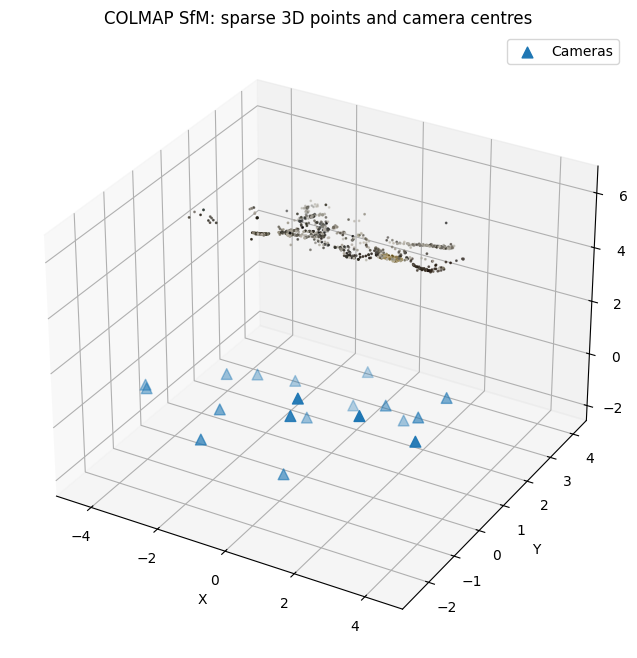

In [ ]:
# Remove extreme outliers for easier visualization.
if len(xyz) == 0:
    raise RuntimeError("No triangulated points were produced.")

lower = np.percentile(xyz, 2, axis=0)
upper = np.percentile(xyz, 98, axis=0)

keep = np.all((xyz >= lower) & (xyz <= upper), axis=1)

xyz_plot = xyz[keep]
rgb_plot = rgb[keep]

# Subsample if necessary.
max_points = 20000
if len(xyz_plot) > max_points:
    indices = np.random.default_rng(0).choice(
        len(xyz_plot), max_points, replace=False
    )
    xyz_plot = xyz_plot[indices]
    rgb_plot = rgb_plot[indices]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    xyz_plot[:, 0],
    xyz_plot[:, 1],
    xyz_plot[:, 2],
    c=rgb_plot,
    s=1,
)

if len(camera_centres):
    ax.scatter(
        camera_centres[:, 0],
        camera_centres[:, 1],
        camera_centres[:, 2],
        marker="^",
        s=60,
        label="Cameras",
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("COLMAP SfM: sparse 3D points and camera centres")
ax.legend()
plt.show()

## VGGT

In [ ]:
%cd /content

!git clone -q https://github.com/facebookresearch/vggt.git
%cd /content/vggt

!pip -q install -r requirements.txt

/content
fatal: destination path 'vggt' already exists and is not an empty directory.
/content/vggt
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.5.1+cu121 requires torch==2.5.1, but you have torch 2.3.1 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.1 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.1 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.1 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.1 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.1 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.1 which is incompatible.
shap 0.52.0 requires numpy>

In [ ]:
# Comprehensive fix for numpy/torchvision/torch incompatibility.
# This requires a restart of the runtime after these commands are run.
print("Attempting to fix library incompatibilities...")
!pip uninstall -y numpy torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
print("\nLibrary reinstallation commands executed. \n\n********************************************************\n********************************************************\nPLEASE RESTART YOUR COLAB RUNTIME (Runtime -> Restart runtime) NOW for the changes to take effect.\n********************************************************\n********************************************************")

Attempting to fix library incompatibilities...
Found existing installation: numpy 1.26.1
Uninstalling numpy-1.26.1:
  Successfully uninstalled numpy-1.26.1
Found existing installation: torch 2.3.1
Uninstalling torch-2.3.1:
  Successfully uninstalled torch-2.3.1
Found existing installation: torchvision 0.18.1
Uninstalling torchvision-0.18.1:
  Successfully uninstalled torchvision-0.18.1
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
  Using cached https://download.pytorch.org/whl/cu121/


Library reinstallation commands executed. 

********************************************************
********************************************************
PLEASE RESTART YOUR COLAB RUNTIME (Runtime -> Restart runtime) NOW for the changes to take effect.
********************************************************
********************************************************


In [ ]:
import sys
sys.path.insert(0, "/content/vggt")

import torch
from vggt.models.vggt import VGGT
from vggt.utils.load_fn import load_and_preprocess_images

device = "cuda" if torch.cuda.is_available() else "cpu"

if device != "cuda":
    print("Warning: VGGT is large. Enable a GPU runtime for practical inference.")

if device == "cuda":
    major, _ = torch.cuda.get_device_capability()
    dtype = torch.bfloat16 if major >= 8 else torch.float16
else:
    dtype = torch.float32

print("Device:", device)
print("Inference dtype:", dtype)

# Start with 4–8 images if GPU memory is limited.
vggt_image_paths = [str(path) for path in image_paths[:8]]

images = load_and_preprocess_images(vggt_image_paths).to(device)

print("Number of images:", len(vggt_image_paths))
print("Preprocessed tensor shape:", tuple(images.shape))

Device: cuda
Inference dtype: torch.float16
Number of images: 8
Preprocessed tensor shape: (8, 3, 392, 518)


In [ ]:
model = VGGT.from_pretrained("facebook/VGGT-1B").to(device)
model.eval()

print("VGGT loaded.")

config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 5.03GB            

model.safetensors: downloading bytes:           |  0.00B            

VGGT loaded.


feed-forward reconstruction

In [ ]:
torch.cuda.empty_cache()

with torch.no_grad():
    if device == "cuda":
        with torch.autocast(device_type="cuda", dtype=dtype):
            predictions = model(images)
    else:
        predictions = model(images)

print("VGGT output keys:")
for key, value in predictions.items():
    if torch.is_tensor(value):
        print(f"{key:25s}: shape={tuple(value.shape)}, dtype={value.dtype}")
    else:
        print(f"{key:25s}: {type(value)}")

/content/vggt/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


VGGT output keys:
pose_enc                 : shape=(1, 8, 9), dtype=torch.float32
pose_enc_list            : <class 'list'>
depth                    : shape=(1, 8, 392, 518, 1), dtype=torch.float32
depth_conf               : shape=(1, 8, 392, 518), dtype=torch.float32
world_points             : shape=(1, 8, 392, 518, 3), dtype=torch.float32
world_points_conf        : shape=(1, 8, 392, 518), dtype=torch.float32
images                   : shape=(1, 8, 3, 392, 518), dtype=torch.float32


In [ ]:
# vggt outputs to numpy
pred_np = {}

for key, value in predictions.items():
    if torch.is_tensor(value):
        pred_np[key] = value.detach().float().cpu().numpy()
    else:
        pred_np[key] = value

for key, value in pred_np.items():
    if hasattr(value, "shape"):
        print(key, value.shape)

pose_enc (1, 8, 9)
depth (1, 8, 392, 518, 1)
depth_conf (1, 8, 392, 518)
world_points (1, 8, 392, 518, 3)
world_points_conf (1, 8, 392, 518)
images (1, 8, 3, 392, 518)


inspect camera outputs

In [ ]:
for possible_key in ["pose_enc", "extrinsic", "extrinsics", "intrinsic", "intrinsics"]:
    if possible_key in pred_np:
        print("\n", possible_key)
        print(pred_np[possible_key])


 pose_enc
[[[ 9.6995595e-05 -3.2467087e-05  2.3937937e-05  5.0480670e-05
   -1.0655436e-04 -1.5268339e-05  1.0000520e+00  8.3938986e-01
    1.0623181e+00]
  [-3.5189921e-01 -6.8864636e-02 -5.0369177e-02  1.3543987e-01
    1.2807193e-01  7.5253761e-01  6.3090765e-01  8.1163079e-01
    1.0329021e+00]
  [-4.9823955e-01 -2.6052320e-01  8.6118132e-02  2.7200976e-02
    2.8136462e-01  5.5551237e-01  7.8148955e-01  8.5155708e-01
    1.0768174e+00]
  [-4.7086221e-01 -5.6562239e-01  1.1938188e-01 -1.0334884e-01
    3.4221190e-01  5.5566204e-01  7.4967301e-01  8.3920580e-01
    1.0616902e+00]
  [-5.1008439e-01 -8.3072394e-01  4.6744630e-01 -6.0890954e-02
    5.4785901e-01  7.0431811e-01  4.4626978e-01  8.4866303e-01
    1.0727104e+00]
  [-5.0604057e-01 -6.3325351e-01  2.3014206e-01 -4.8504978e-02
    4.3211281e-01  6.9844013e-01  5.6759089e-01  8.4088528e-01
    1.0623357e+00]
  [-4.6980366e-01 -1.1238895e-01  6.8049006e-02  1.5592697e-01
    1.7670493e-01  8.2378364e-01  5.1480502e-01  8.23568

predicted depth maps:

In [ ]:
depth_key = None

for candidate in ["depth", "depths", "depth_map", "depth_maps"]:
    if candidate in predictions:
        depth_key = candidate
        break

if depth_key is None:
    print("No obvious depth key found.")
    print("Available keys:", list(predictions.keys()))
else:
    depth = predictions[depth_key].detach().float().cpu().numpy()
    depth = np.squeeze(depth)

    print("Depth key:", depth_key)
    print("Depth shape after squeeze:", depth.shape)

Depth key: depth
Depth shape after squeeze: (8, 392, 518)


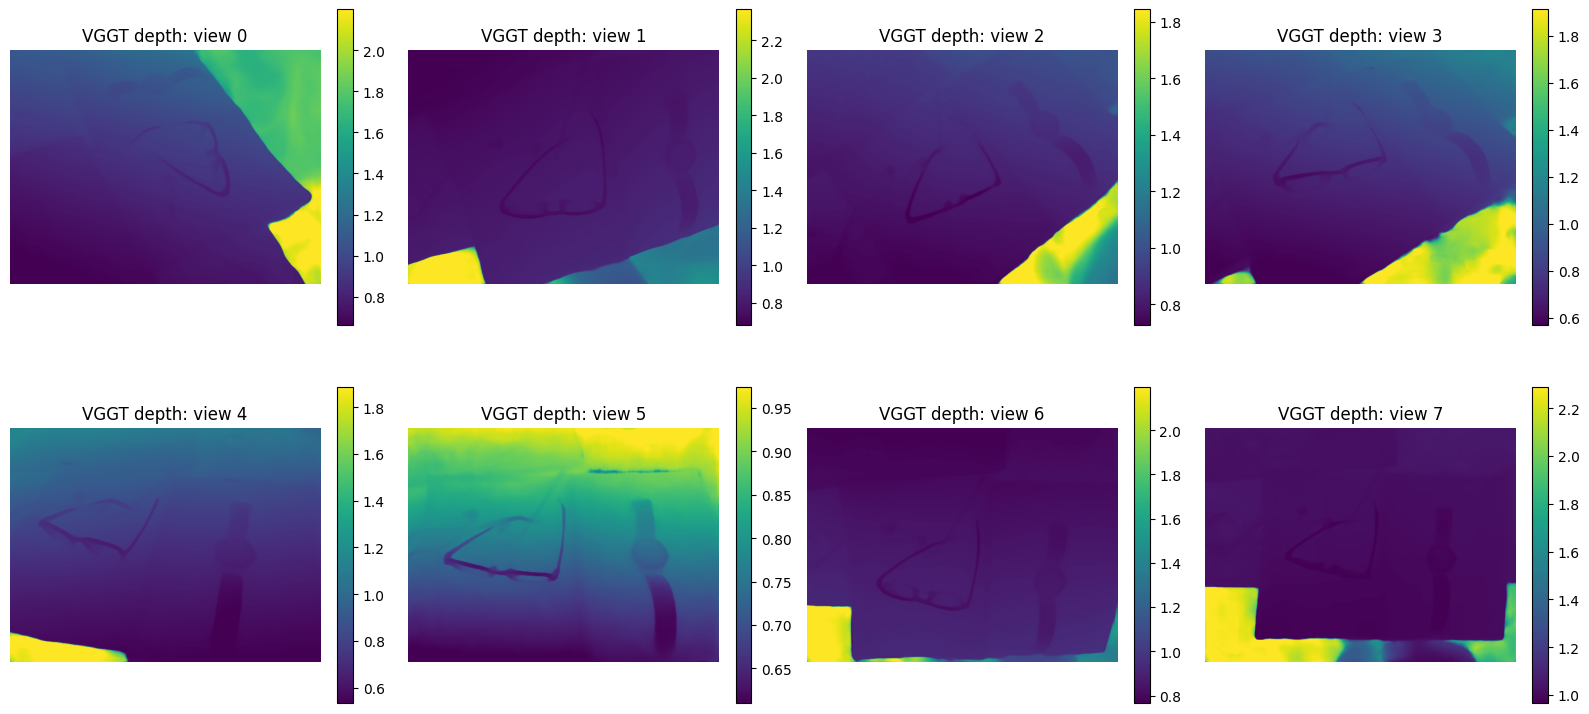

In [ ]:
import math
if depth_key is not None:
    # Normalize possible output arrangements into [N, H, W].
    if depth.ndim == 2:
        depth_views = depth[None]
    elif depth.ndim == 3:
        depth_views = depth
    elif depth.ndim == 4 and depth.shape[-1] == 1:
        depth_views = depth[..., 0]
    elif depth.ndim == 4 and depth.shape[1] == 1:
        depth_views = depth[:, 0]
    else:
        raise ValueError(f"Unexpected depth shape: {depth.shape}")

    n_show = min(len(depth_views), 8)
    cols = 4
    rows = math.ceil(n_show / cols)

    plt.figure(figsize=(16, 4 * rows))

    for index in range(n_show):
        depth_i = depth_views[index]

        # Robust visualization range.
        finite = np.isfinite(depth_i)
        vmin, vmax = np.percentile(depth_i[finite], [2, 98])

        plt.subplot(rows, cols, index + 1)
        plt.imshow(depth_i, vmin=vmin, vmax=vmax)
        plt.colorbar(fraction=0.046)
        plt.title(f"VGGT depth: view {index}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

point-map

In [ ]:
point_key = None

for candidate in ["world_points", "point_map", "point_maps", "points"]:
    if candidate in predictions:
        point_key = candidate
        break

if point_key is None:
    print("No obvious point-map key found.")
    print("Available keys:", list(predictions.keys()))
else:
    point_maps = predictions[point_key].detach().float().cpu().numpy()
    print("Point-map key:", point_key)
    print("Raw point-map shape:", point_maps.shape)

Point-map key: world_points
Raw point-map shape: (1, 8, 392, 518, 3)


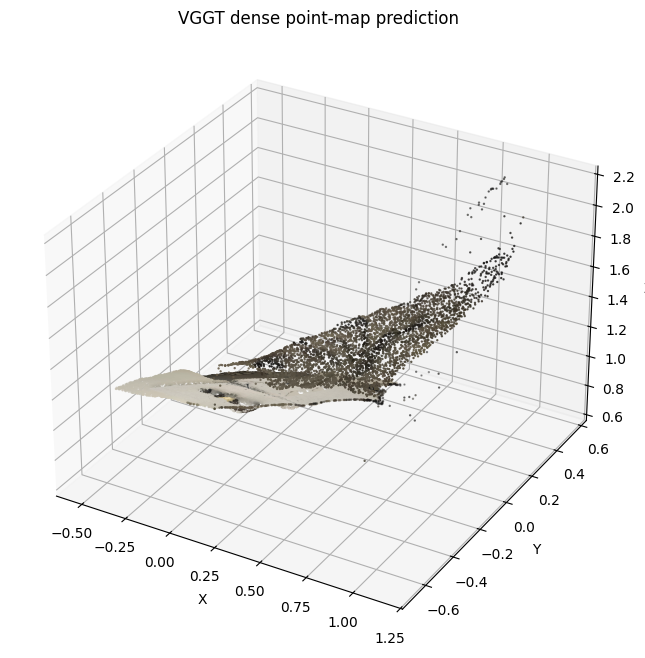

In [ ]:
if point_key is not None:
    points = np.squeeze(point_maps)

    # Try to normalize to [N, H, W, 3].
    if points.ndim == 3 and points.shape[-1] == 3:
        points_views = points[None]
    elif points.ndim == 4 and points.shape[-1] == 3:
        points_views = points
    elif points.ndim == 4 and points.shape[1] == 3:
        points_views = np.moveaxis(points, 1, -1)
    else:
        raise ValueError(
            f"Unexpected point-map shape {points.shape}. "
            "Inspect the printed output keys and shapes."
        )

    view_index = 0
    points_view = points_views[view_index].reshape(-1, 3)

    # Use the corresponding preprocessed RGB image if accessible.
    rgb_image = images[view_index].detach().float().cpu()

    # Convert CHW to HWC.
    if rgb_image.ndim == 3:
        rgb_image = rgb_image.permute(1, 2, 0).numpy()
    else:
        rgb_image = np.ones(
            (
                points_views.shape[1],
                points_views.shape[2],
                3,
            )
        )

    # Map approximately to visible range.
    rgb_image = rgb_image - rgb_image.min()
    rgb_image = rgb_image / (rgb_image.max() + 1e-8)
    colours = rgb_image.reshape(-1, 3)

    valid = np.isfinite(points_view).all(axis=1)
    points_view = points_view[valid]
    colours = colours[valid]

    # Remove extreme predictions for visualization.
    lower = np.percentile(points_view, 2, axis=0)
    upper = np.percentile(points_view, 98, axis=0)
    keep = np.all(
        (points_view >= lower) & (points_view <= upper),
        axis=1,
    )

    points_view = points_view[keep]
    colours = colours[keep]

    max_points = 30000
    if len(points_view) > max_points:
        indices = np.random.default_rng(0).choice(
            len(points_view),
            max_points,
            replace=False,
        )
        points_view = points_view[indices]
        colours = colours[indices]

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        points_view[:, 0],
        points_view[:, 1],
        points_view[:, 2],
        c=colours,
        s=0.5,
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("VGGT dense point-map prediction")
    plt.show()

## NeRF

# 3D GS

# LIFF dataset testing

In [ ]:
pip install gdown

In [ ]:
!gdown https://drive.google.com/uc?id=11PhkBXZZNYTD2emdG1awALlhCnkq7aN-

Downloading...
From (original): https://drive.google.com/uc?id=11PhkBXZZNYTD2emdG1awALlhCnkq7aN-
From (redirected): https://drive.google.com/uc?id=11PhkBXZZNYTD2emdG1awALlhCnkq7aN-&confirm=t&uuid=06d89da4-d541-4e23-aa42-4c18e5166acf
To: /content/nerf_llff_data.zip
100% 1.79G/1.79G [00:24<00:00, 72.8MB/s]


In [ ]:
!unzip nerf_llff_data.zip

Archive:  nerf_llff_data.zip
replace nerf_llff_data/flower/images_4/image024.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: nerf_llff_data/flower/images_4/image024.png  
replace nerf_llff_data/flower/images_4/image004.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: nerf_llff_data/flower/images_4/image004.png  
replace nerf_llff_data/flower/images_4/image011.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: nerf_llff_data/flower/images_4/image011.png  
replace nerf_llff_data/flower/images_4/image022.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: nerf_llff_data/flower/images_4/image022.png  
replace nerf_llff_data/flower/images_4/image009.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: nerf_llff_data/flower/images_4/image009.png  
replace nerf_llff_data/flower/images_4/image003.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 
error:  invalid response [{ENTER}]
replace nerf_llff_data/flower/images_4/image003.png? [y]es, [n]o, [A]ll, [N]one, [r]

### Visualizing images from the dataset

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import os

DATA_ROOT = Path("/content/nerf_llff_data")
scenes_to_plot = ["room", "fern"]

for scene in scenes_to_plot:
    print(f"\n--- Checking scene: {scene} ---")
    image_dir_options = [DATA_ROOT / scene / "images", DATA_ROOT / scene / "images_4"]
    found_image_dir = None

    for img_dir in image_dir_options:
        if img_dir.is_dir() and any(img_dir.iterdir()):
            found_image_dir = img_dir
            break

    if found_image_dir:
        print(f"Found images in: {found_image_dir}")
        all_images = sorted(list(found_image_dir.glob("*.jpg"))) + sorted(list(found_image_dir.glob("*.png")))

        if not all_images:
            print(f"No images found in {found_image_dir}.")
            continue

        # Take a sample of up to 4 images
        sample_images = all_images[:min(len(all_images), 4)]

        plt.figure(figsize=(15, 4))
        plt.suptitle(f"Sample images from the '{scene}' scene", fontsize=16)

        for i, img_path in enumerate(sample_images):
            try:
                img = Image.open(img_path)
                plt.subplot(1, len(sample_images), i + 1)
                plt.imshow(img)
                plt.title(img_path.name, fontsize=8)
                plt.axis("off")
            except Exception as e:
                print(f"Could not load image {img_path.name}: {e}")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print(f"No image directory found for scene '{scene}' in {image_dir_options}. Make sure the dataset contains this scene.")

# Inform the user if 'fern' was explicitly not found
if not (DATA_ROOT / "fern").is_dir():
    print("\nNote: The 'fern' directory was not found in the unzipped dataset. Only 'room' images were processed if available.")



--- Checking scene: room ---
Found images in: /content/nerf_llff_data/room/images
No images found in /content/nerf_llff_data/room/images.

--- Checking scene: fern ---
Found images in: /content/nerf_llff_data/fern/images
No images found in /content/nerf_llff_data/fern/images.


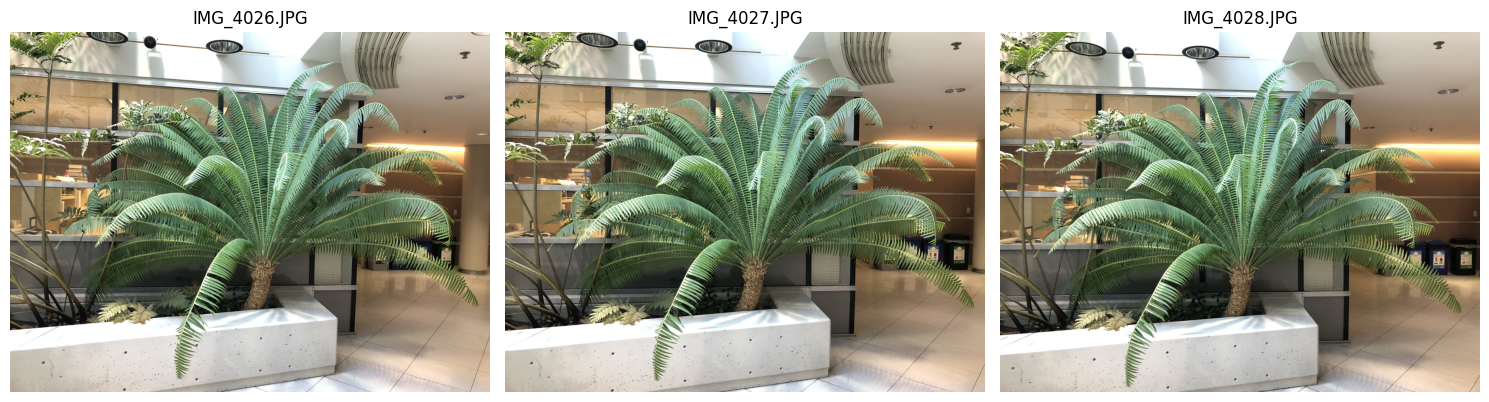

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Paths to the first 3 images based on your file tree
img_paths = [
    'nerf_llff_data/fern/images/IMG_4026.JPG',
    'nerf_llff_data/fern/images/IMG_4027.JPG',
    'nerf_llff_data/fern/images/IMG_4028.JPG'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, path in zip(axes, img_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(path.split('/')[-1])

plt.tight_layout()
plt.show()


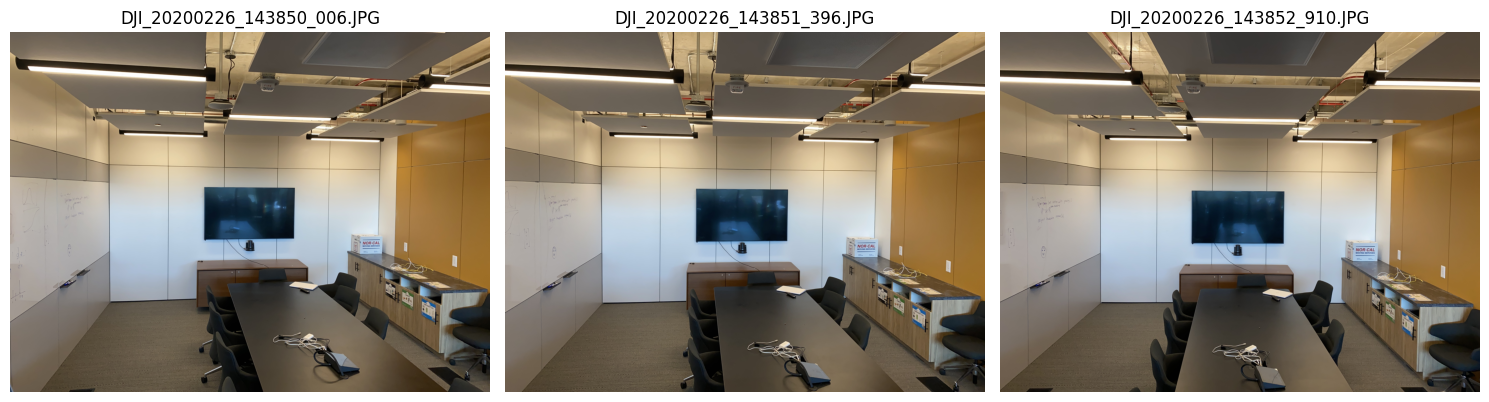

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Paths to the first 3 images based on your file tree
img_paths = [
    '/content/nerf_llff_data/room/images/DJI_20200226_143850_006.JPG',
    '/content/nerf_llff_data/room/images/DJI_20200226_143851_396.JPG',
    '/content/nerf_llff_data/room/images/DJI_20200226_143852_910.JPG'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, path in zip(axes, img_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(path.split('/')[-1])

plt.tight_layout()
plt.show()

# **VGGT + 3DGS** vs **QuantVGGT + 3DGS**

will follow soon